# Walkthrough: is the asteroid belt's compositional gradient primordial?

This notebook drives the `beltgradient` package step by step and shows the intermediate tables behind the paper. The same run is `belt-gradient run` from the command line. Inputs come from `belt-gradient fetch`.

| step | module |
|---|---|
| catalog, main belt, label tiers | `catalog` |
| families, proper elements, collapse | `families` |
| completeness, size-complete limit, IPW | `completeness` |
| C-fraction vs a, crossover | `gradient` |
| orbital excitation | `orbits` |
| label-free albedo check | `albedo` |

In [1]:
from IPython.display import Image, display
import pandas as pd
from beltgradient.config import Paths
from beltgradient.pipeline import run, FIGURE_FILES

pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
paths = Paths.default()
res = run(paths, write=False)   # write=True also rewrites figures/ and results/summary.json
T = res.tables

snapshot: 1,555,667 rows | catalog_date 2026-08-11 | pipeline 1.1.0


main belt (2.1-3.3 AU): 1,431,660 | taxonomy tier 161,646


families: 272 | in a family: 10.7% (one-step extension would attach 229,745 -> 26.8%)


H_c = 10.5 -> D_complete = 52.8 km


crossover a50: {'raw': 2.841, 'collapsed, IPW, D≥10 km': 2.463, 'collapsed, D≥53 km': 2.472, 'background, D≥53 km': 2.407}


## Label provenance

Only `taxonomy` (published classifications) is used. `assumed` labels come from an albedo chosen by semimajor axis, so they would return the gradient by construction.

In [2]:
mb = res.frames["main_belt"]
mb.tier.value_counts()

tier
assumed         1189706
taxonomy         161646
albedo_proxy      80304
none                  4
Name: count, dtype: int64

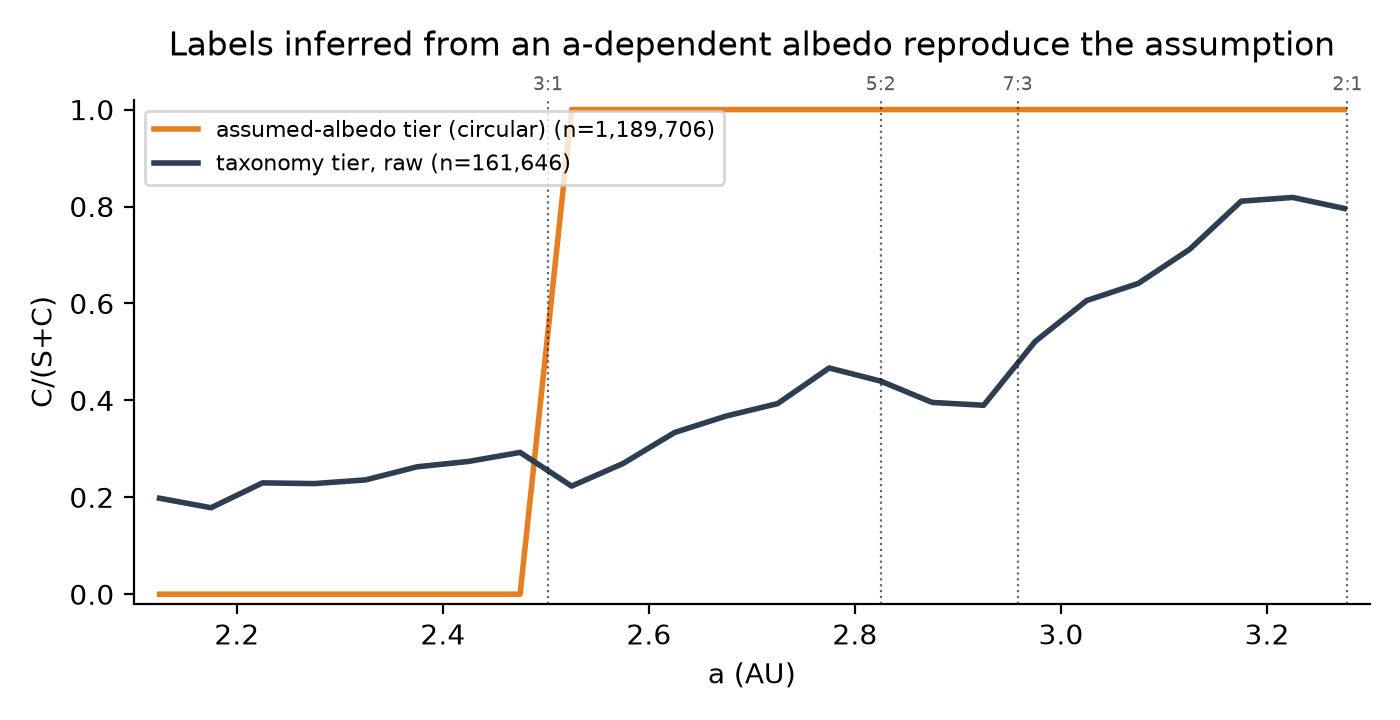

In [3]:
display(Image(paths.figures / FIGURE_FILES["circularity"][0], width=620))

## Collisional families

Each family is collapsed to one body: majority class of ≥ 3 labelled members, otherwise the largest member's own label. `purity` is the fraction of labelled members in that class.

In [4]:
T["families"].head(15)[["fam_name", "n_members", "D_equiv_km", "a_rep", "fam_group", "purity", "n_labelled", "largest"]].round(3)

,fam_name,n_members,D_equiv_km,a_rep,fam_group,purity,n_labelled,largest
fam_id,,,,,,,,
2015_405,Nysa-Polana,19073,114.511,2.427,S-like,0.657,5839.0,Hertha
2015_401,Vesta,15252,524.927,2.361,S-like,0.927,6546.0,Vesta
2015_402,Flora,13760,221.981,2.387,S-like,0.744,5056.0,Metis
2015_606,Eos,9789,190.965,3.012,S-like,0.436,3166.0,Eos
2015_404,Massalia,6424,137.268,2.408,S-like,0.708,1276.0,Massalia
2015_605,Koronis,5949,104.220,2.893,S-like,0.733,1803.0,Lacrimosa
2015_502,Eunomia,5670,264.105,2.642,S-like,0.824,2699.0,Eunomia
2015_601,Hygiea,4854,465.619,3.151,C-like,0.905,1833.0,Hygiea
2015_602,Themis,4782,285.775,3.144,C-like,0.924,1794.0,Themis


## Completeness

The faintest H at which every zone is ≥ 95% classified sets the size-complete limit.

{'H_c': 10.5, 'D_complete_km': np.float64(52.8), 'H_c_albedo': 11.5, 'D_complete_albedo_km': np.float64(33.3)}


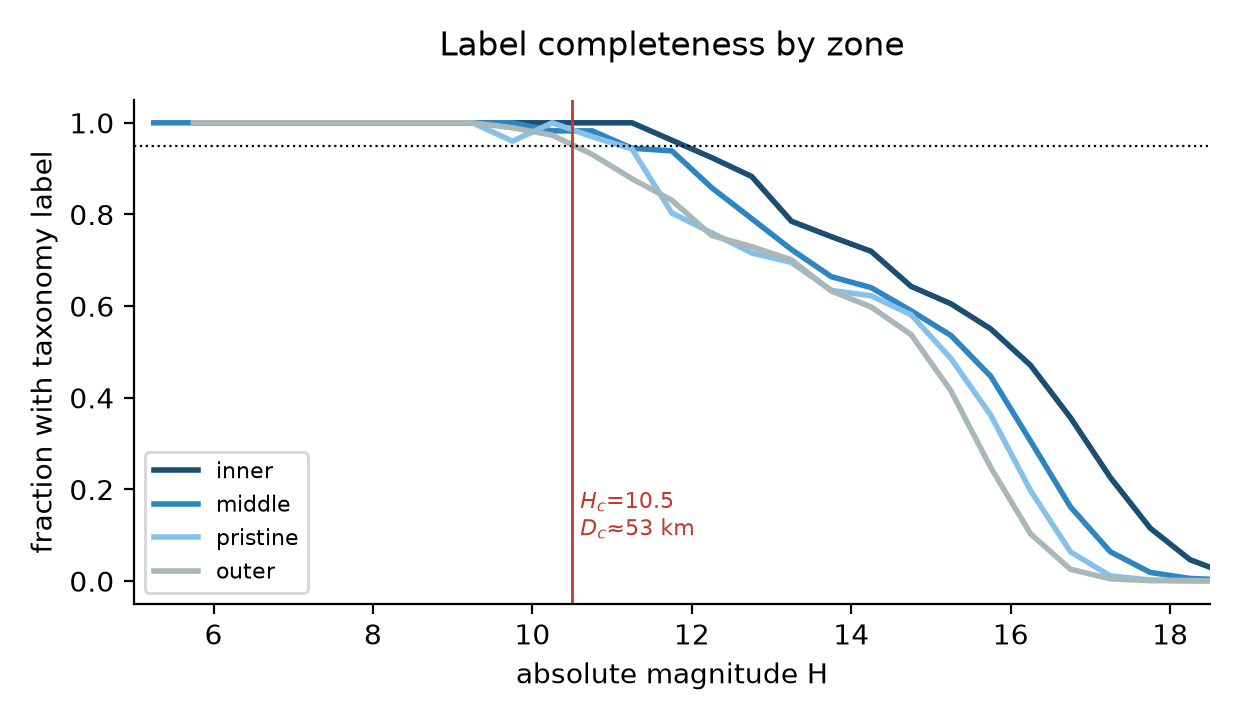

In [5]:
print(res.summary["completeness"])
display(Image(paths.figures / FIGURE_FILES["completeness"][0], width=560))

## C-fraction versus semimajor axis

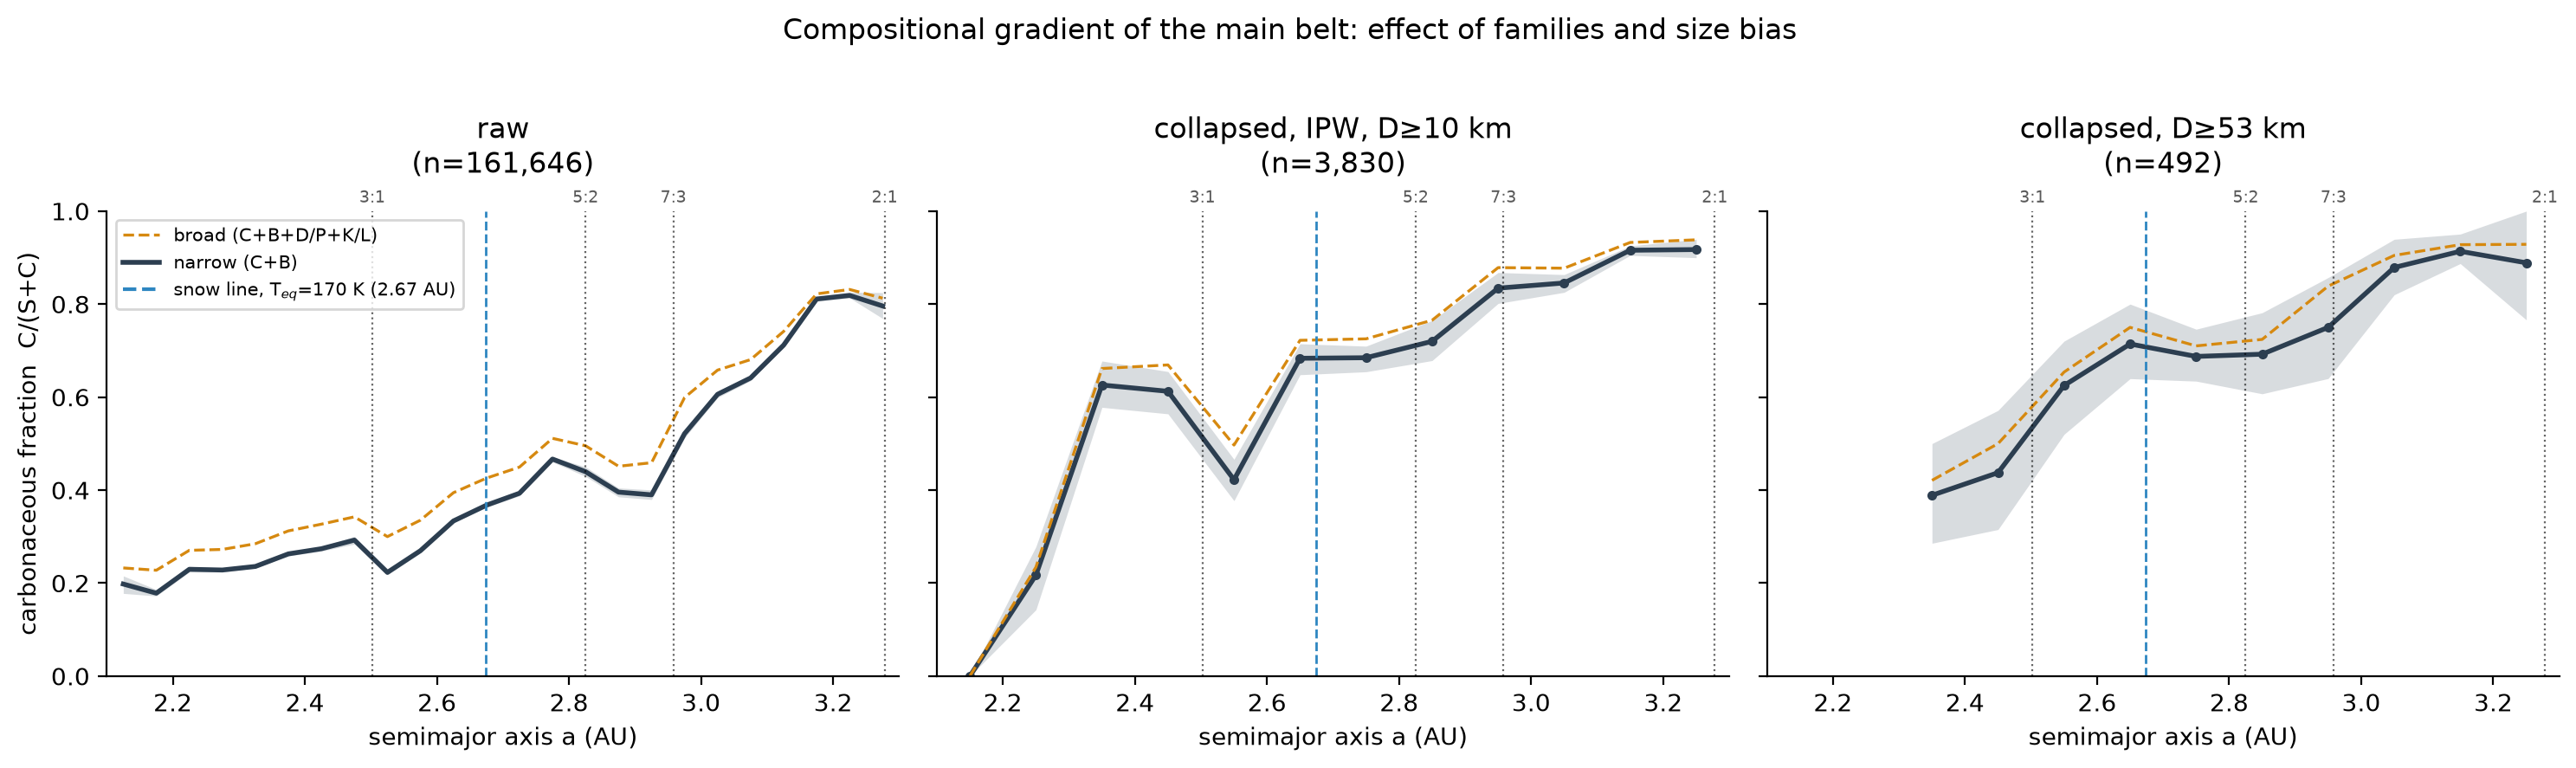

,inner,middle,pristine,outer
raw,0.25 [0.24–0.25] (n=49690),0.35 [0.34–0.35] (n=48943),0.40 [0.39–0.40] (n=5155),0.70 [0.69–0.70] (n=31581)
"collapsed, IPW, D≥10 km",0.52 [0.49–0.55] (n=231),0.63 [0.61–0.65] (n=661),0.77 [0.73–0.81] (n=128),0.90 [0.89–0.91] (n=1269)
"collapsed, D≥53 km",0.41 [0.31–0.49] (n=39),0.68 [0.64–0.73] (n=129),0.70 [0.61–0.77] (n=30),0.89 [0.87–0.92] (n=133)
"background, D≥53 km",0.46 [0.35–0.56] (n=24),0.71 [0.66–0.75] (n=96),0.71 [0.61–0.83] (n=21),0.91 [0.88–0.93] (n=106)


In [6]:
display(Image(paths.figures / FIGURE_FILES["c_fraction"][0], width=980))
T["zone_narrow"]

In [7]:
T["zone_broad"]

,inner,middle,pristine,outer
raw,0.29 [0.29–0.30] (n=53068),0.41 [0.40–0.41] (n=53852),0.46 [0.45–0.46] (n=5743),0.73 [0.73–0.73] (n=35198)
"collapsed, IPW, D≥10 km",0.57 [0.54–0.60] (n=258),0.68 [0.66–0.69] (n=751),0.82 [0.80–0.85] (n=167),0.92 [0.91–0.93] (n=1622)
"collapsed, D≥53 km",0.47 [0.38–0.53] (n=43),0.71 [0.67–0.75] (n=141),0.78 [0.72–0.84] (n=40),0.92 [0.89–0.94] (n=167)
"background, D≥53 km",0.52 [0.42–0.61] (n=27),0.74 [0.69–0.78] (n=107),0.81 [0.74–0.88] (n=31),0.93 [0.90–0.95] (n=139)


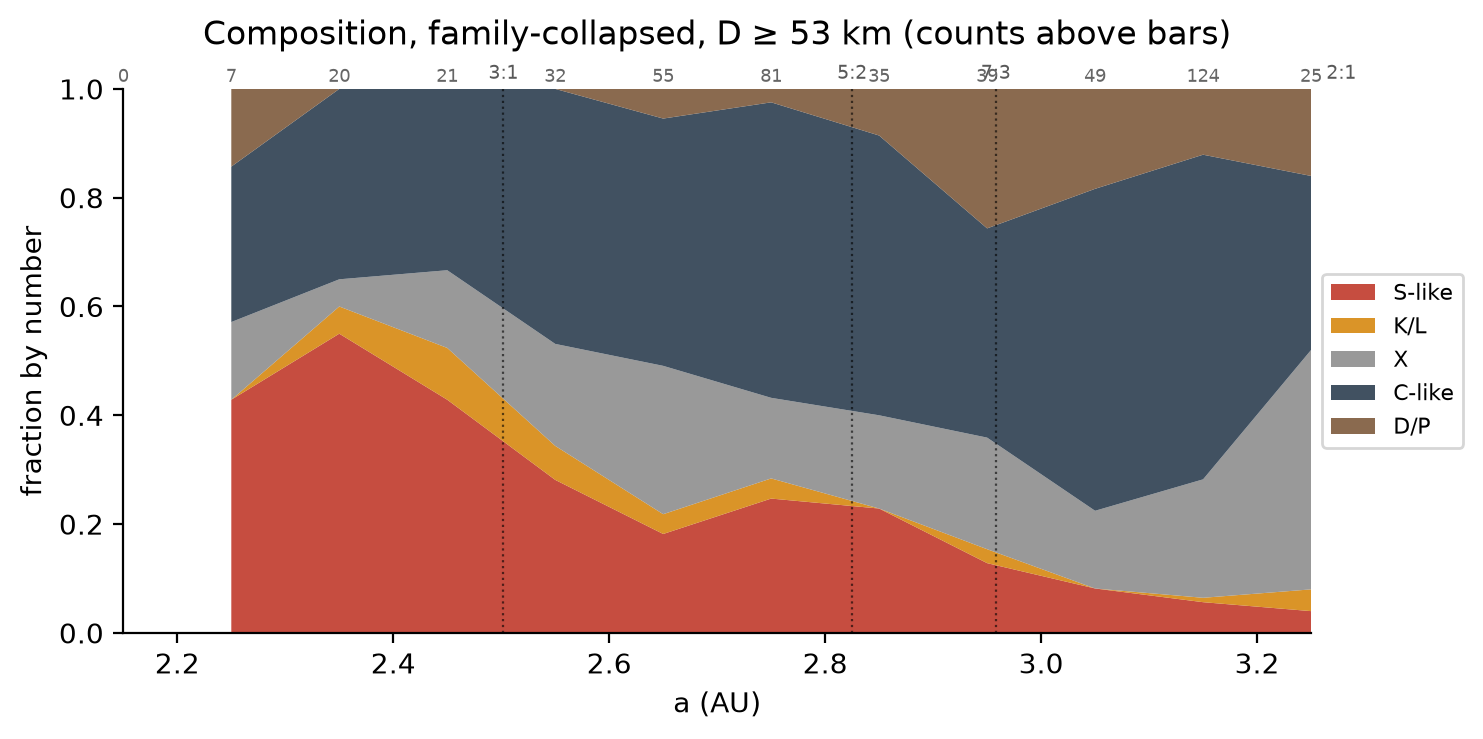

In [8]:
display(Image(paths.figures / FIGURE_FILES["stacked"][0], width=680))

## Inner belt by size and by mass (compare DeMeo & Carry 2014)

Families included. The 5–20 km bin is not debiased, so its C-fraction is a lower limit.

,size,n_S,n_C,C_frac_number,C_frac_mass
0,>= 100 km,10,3,0.231,0.039
1,50-100 km,16,18,0.529,0.460
2,20-50 km,25,37,0.597,0.372
3,5-20 km,1106,1068,0.491,0.340


mass-weighted C/(S+C) by zone: {'all': {'inner': 0.063, 'middle': 0.906, 'pristine': 0.715, 'outer': 0.939}, 'no_big4': {'inner': 0.263, 'middle': 0.499, 'pristine': 0.715, 'outer': 0.923}}


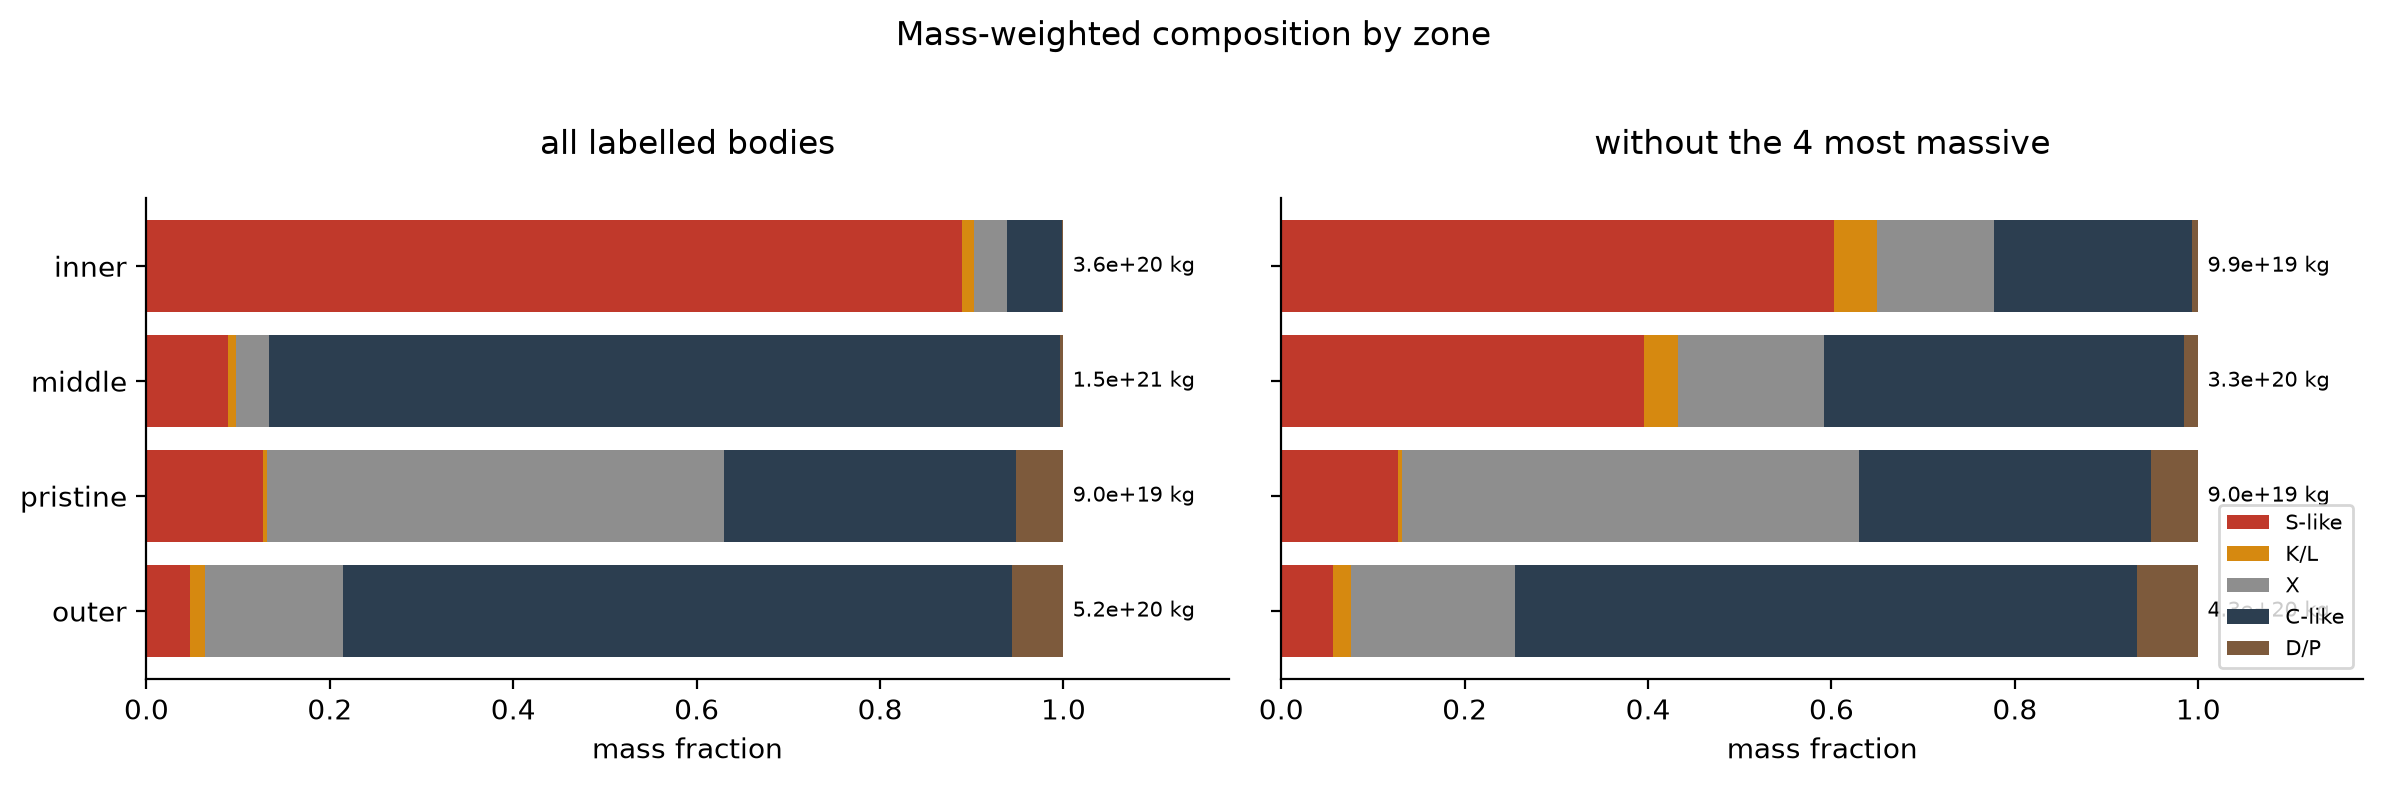

In [9]:
display(T["inner_by_size"].round(3))
print("mass-weighted C/(S+C) by zone:", res.summary["mass_c_fraction"])
display(Image(paths.figures / FIGURE_FILES["mass"][0], width=900))

## Where do S and C cross over?

Logistic fit P(C | a); a₅₀ and the 10→90% width, with 16–84% bootstrap intervals. The classical snow line (T_eq = 170 K) is at 2.67 AU.

In [10]:
T["crossover"].astype(float).round(3)

,a50,a50_lo,a50_hi,width_10_90,width_lo,width_hi,n
raw,2.841,2.838,2.844,1.717,1.705,1.733,135369.0
"collapsed, IPW, D≥10 km",2.463,2.430,2.485,1.379,1.315,1.472,2289.0
"collapsed, D≥53 km",2.472,2.392,2.516,1.391,1.203,1.684,331.0
"background, D≥53 km",2.407,2.308,2.482,1.486,1.228,1.848,247.0


## Orbital excitation

Background bodies with D ≥ 10 km, KS per zone and element, Bonferroni over 8 tests.

,zone,element,n_S,n_C,median_S,median_C,dmedian_C_minus_S,ci95_lo,ci95_hi,KS_D,KS_p,bonferroni_sig
0,inner,proper e,103,103,0.1555,0.1542,-0.0014,-0.0128,0.0159,0.1165,0.4887,False
1,inner,proper sin i,103,103,0.0983,0.0852,-0.0131,-0.0366,0.0238,0.1456,0.2254,False
2,middle,proper e,235,354,0.1499,0.1596,0.0097,-0.0046,0.0291,0.1202,0.0304,False
3,middle,proper sin i,235,354,0.1704,0.1498,-0.0206,-0.0378,-0.0045,0.1168,0.0382,False
4,pristine,proper e,24,77,0.1133,0.1752,0.0619,-0.0005,0.1219,0.3182,0.0378,False
5,pristine,proper sin i,24,77,0.1251,0.2169,0.0918,0.0051,0.1693,0.3258,0.0311,False
6,outer,proper e,137,1083,0.1215,0.1346,0.0131,-0.0037,0.0363,0.1270,0.0357,False
7,outer,proper sin i,137,1083,0.1994,0.2005,0.0011,-0.0147,0.0191,0.1514,0.0067,False


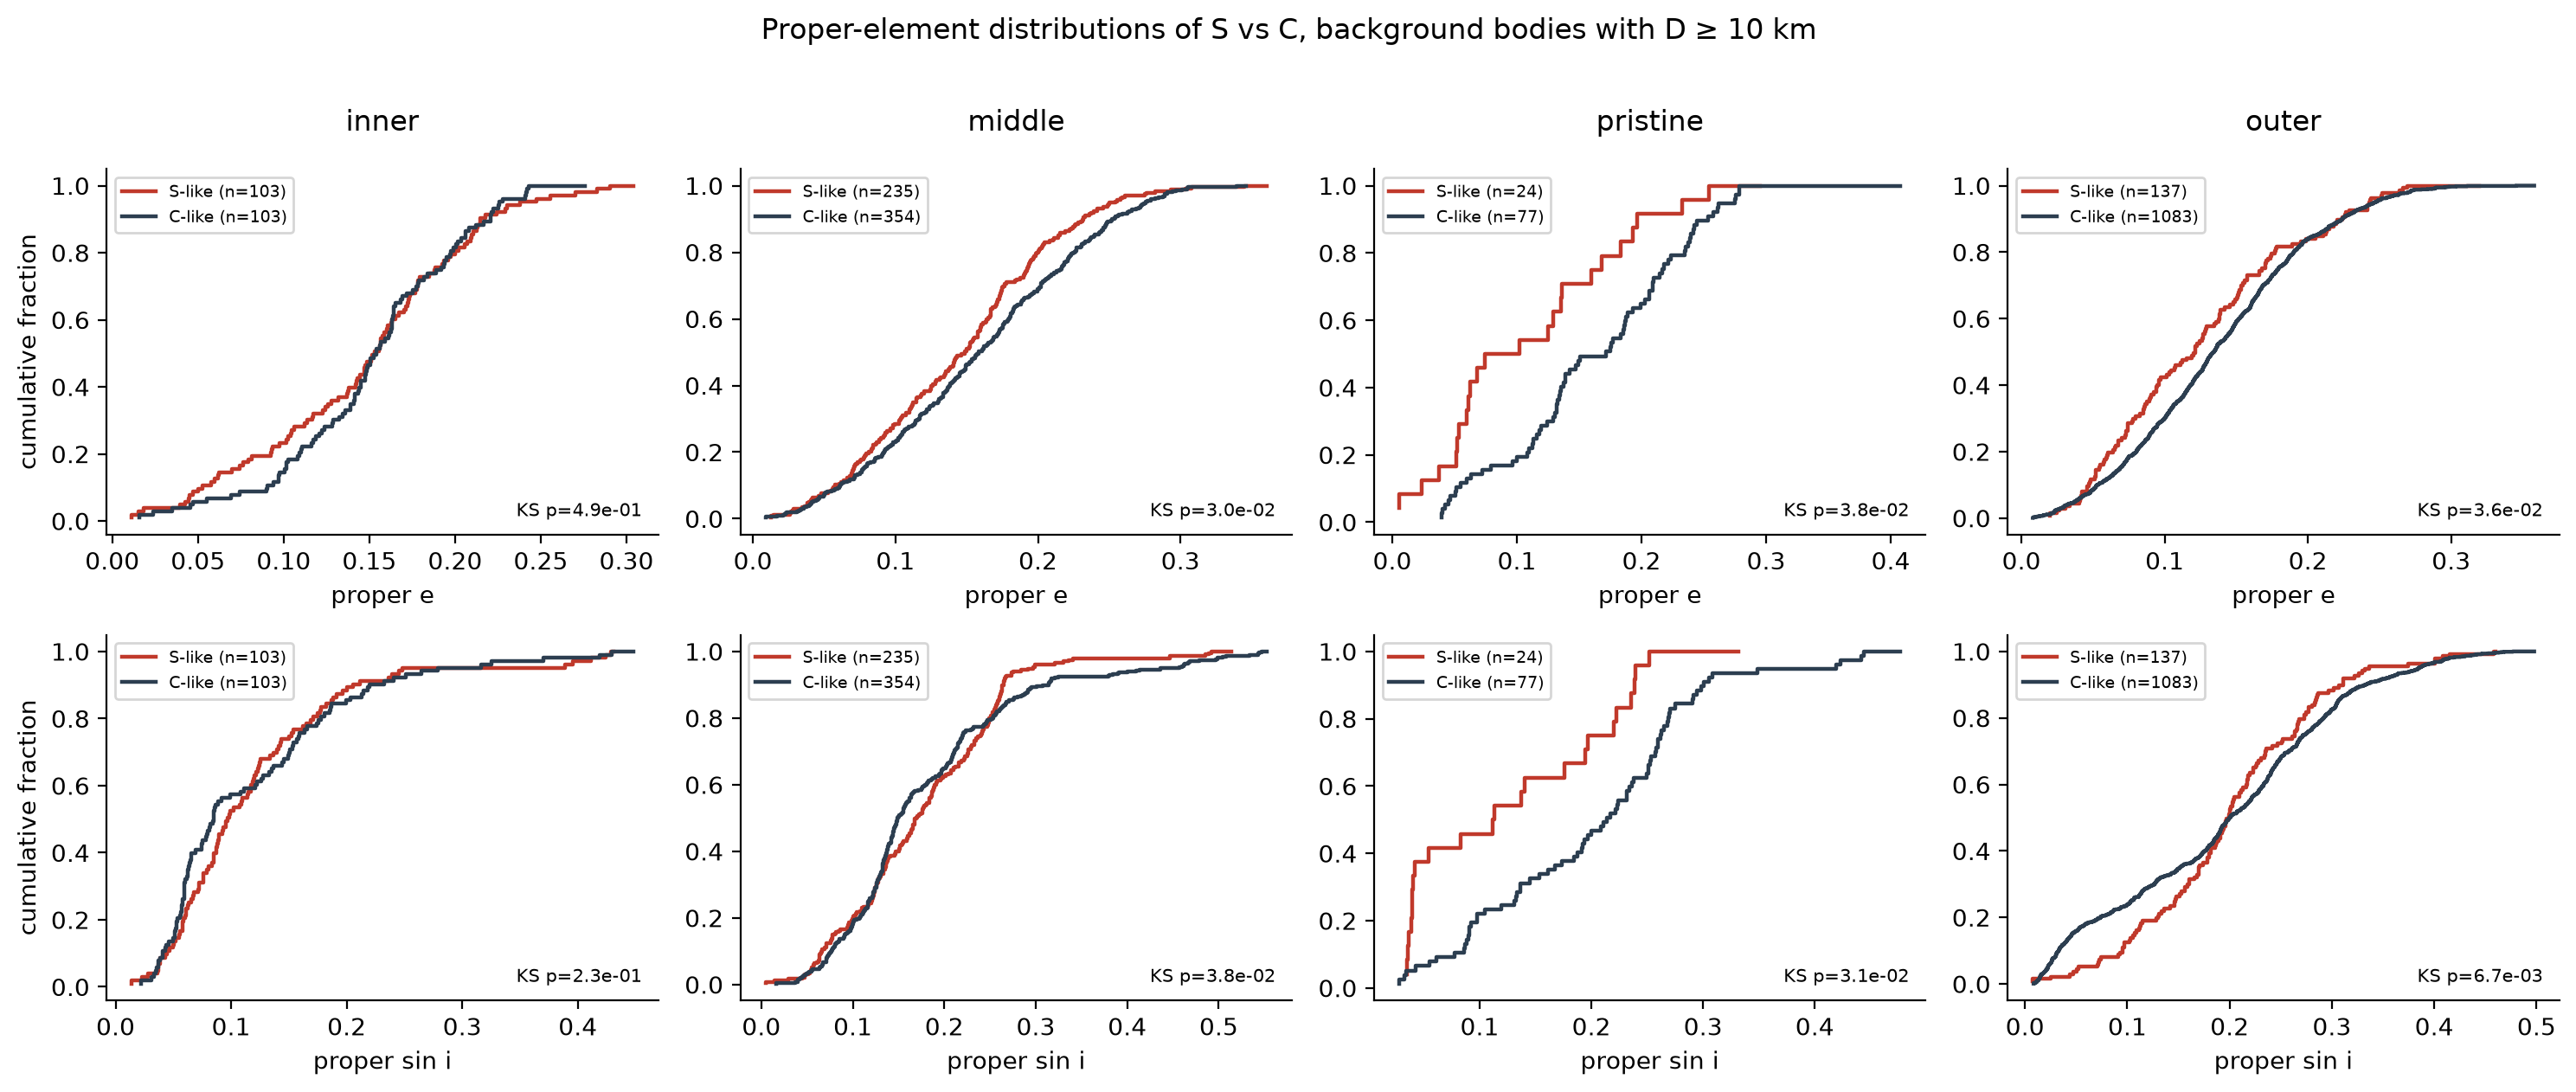

In [11]:
display(T["orbit_tests"].round(4))
display(Image(paths.figures / FIGURE_FILES["orbits"][0], width=980))

## Robustness

Label-free check: the dark fraction from measured albedo alone.

,mean,size
zone,,
inner,0.450,60
middle,0.658,225
pristine,0.789,71
outer,0.821,336


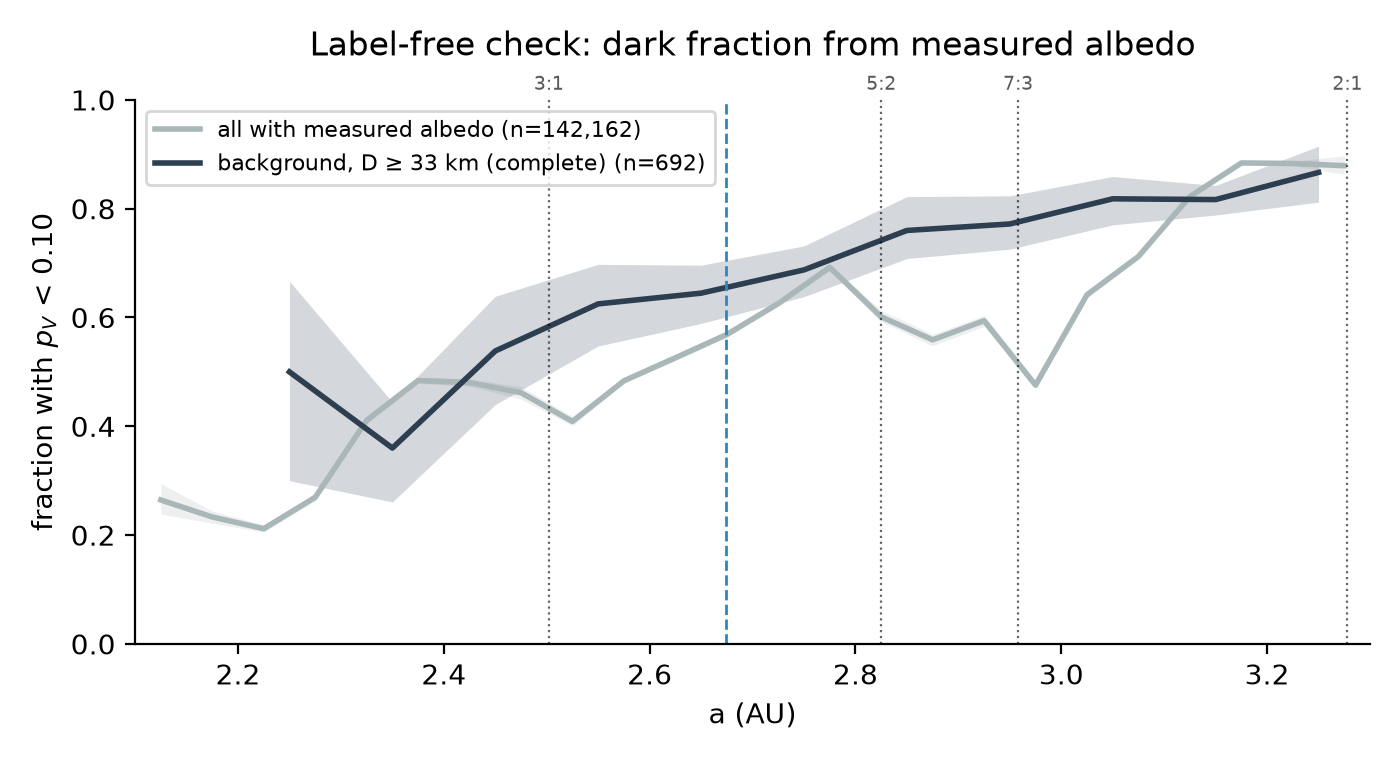

In [12]:
display(T["dark_zone"].round(3))
display(Image(paths.figures / FIGURE_FILES["dark"][0], width=620))

One-step family extension: an aggressive upper bound on missed family members.

In [13]:
ext = res.summary["family_extension_toggled"]
print(f"family fraction {res.summary['families']['family_fraction']:.3f} -> {ext['family_fraction']:.3f}")
print(f"max change in a zone fraction: {ext['max_abs_change_zone_fraction']}, in a50: {ext['max_abs_change_a50_au']} AU")
T["zone_narrow_extended"]

family fraction 0.107 -> 0.268
max change in a zone fraction: 0.02, in a50: 0.0279 AU


,inner,middle,pristine,outer
raw,0.25 [0.24–0.25] (n=49690),0.35 [0.34–0.35] (n=48943),0.40 [0.39–0.40] (n=5155),0.70 [0.69–0.70] (n=31581)
"collapsed, IPW, D≥10 km",0.53 [0.49–0.56] (n=211),0.63 [0.62–0.65] (n=613),0.78 [0.74–0.82] (n=119),0.89 [0.88–0.90] (n=1134)
"collapsed, D≥53 km",0.41 [0.33–0.48] (n=37),0.66 [0.61–0.70] (n=128),0.71 [0.62–0.79] (n=31),0.90 [0.88–0.93] (n=126)
"background, D≥53 km",0.45 [0.34–0.55] (n=22),0.70 [0.65–0.75] (n=93),0.71 [0.60–0.81] (n=21),0.91 [0.88–0.94] (n=98)
